# FTM Calibrated Multilateration Analysis

This notebook adds a **per-responder calibration step** before running multilateration,
addressing the large systematic distance biases observed in raw FTM measurements.

## Strategy overview

| Step | What |
|---|---|
| **1. Load** | All quad-test CSV files (r1–r4) |
| **2. Calibrate** | Use **P22** (room centre, equidistant from all responders) as reference; fit per-responder offset with simple mean and full linear regression |
| **3. Filter** | Only keep samples where **r1, r2 AND r3** all responded; r4 excluded (RSSI −50 dBm, ~1005 cm error) |
| **4. Multilaterate** | Run three algorithm variants on uncalibrated and both calibrated datasets |
| **5. Compare** | Side-by-side accuracy plots for all method × calibration combinations |

## Calibration basis
Position **P22 = (10.0, 5.0) m** is equidistant from **all four responders**:

$$d = \sqrt{(10-0)^2 + (5-0)^2} = \sqrt{125} \approx 11.18\ \text{m} = 1118\ \text{cm}$$

This makes P22 ideal: any deviation from 1118 cm in a measurement is purely systematic bias.

## Algorithm references
- **LLS** — Algebraic Linear Least Squares (Foy 1976; Schau & Robinson 1987)
- **NLLS/LM** — Nonlinear LS, Levenberg-Marquardt, *unbounded* (Marquardt 1963)
- **Robust NLLS** — NLLS with IRLS-style outlier rejection per anchor

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle
from pathlib import Path
from scipy.optimize import least_squares
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [13, 8]
plt.rcParams['font.size'] = 11

print("FTM Calibrated Multilateration Analysis")
print("=" * 45)

FTM Calibrated Multilateration Analysis


## 1. Load Raw FTM Data

In [10]:
DATA_DIR = Path("data/ftm_quad_tests")

# All four responder positions (r4 loaded for calibration insight but excluded from MLAT)
ALL_RESPONDERS = {
    'r1': (0.0, 0.0),
    'r2': (20.0, 0.0),
    'r3': (0.0, 10.0),
    'r4': (20.0, 10.0),
}
# Only these three are used for trilateration
MLAT_RESPONDERS = {k: v for k, v in ALL_RESPONDERS.items() if k != 'r4'}

CALIB_POSITION  = 'p22'   # room centre — equidistant from all responders
TRUE_DIST_P22   = np.sqrt(10.0**2 + 5.0**2) * 100  # ≈ 1118.03 cm

def load_ftm_csv(filepath):
    """Load FTM CSV, silently skip ESP32 error/warning lines."""
    valid_lines = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#') or line.startswith('E ') or line.startswith('W '):
                continue
            valid_lines.append(line)
    from io import StringIO
    return pd.read_csv(StringIO(''.join(valid_lines)))

position_files = sorted(DATA_DIR.glob("FTM_QUAD_espaceSAT_pos*.csv"))
print(f"Found {len(position_files)} position files:")
for f in position_files:
    print(f"  {f.name}")

all_data = [load_ftm_csv(f) for f in position_files]
df_raw = pd.concat(all_data, ignore_index=True)

# Add true distances immediately (used everywhere)
df_raw['true_dist_cm'] = np.sqrt(
    (df_raw['real_x'] * 100 - df_raw['responder_x'] * 100)**2 +
    (df_raw['real_y'] * 100 - df_raw['responder_y'] * 100)**2
)
df_raw['error_raw_cm'] = df_raw['dist_est_cm'] - df_raw['true_dist_cm']

print(f"\nTotal raw rows : {len(df_raw):,}")
print(f"Positions      : {sorted(df_raw['position'].unique())}")
print(f"Responders     : {sorted(df_raw['responder_label'].unique())}")
print(f"\nP22 true distance to every responder: {TRUE_DIST_P22:.2f} cm")

Found 8 position files:
  FTM_QUAD_espaceSAT_pos11.csv
  FTM_QUAD_espaceSAT_pos12.csv
  FTM_QUAD_espaceSAT_pos13.csv
  FTM_QUAD_espaceSAT_pos21.csv
  FTM_QUAD_espaceSAT_pos22.csv
  FTM_QUAD_espaceSAT_pos31.csv
  FTM_QUAD_espaceSAT_pos32.csv
  FTM_QUAD_espaceSAT_pos33.csv

Total raw rows : 31,576
Positions      : ['p11', 'p12', 'p13', 'p21', 'p22', 'p31', 'p32', 'p33']
Responders     : ['r1', 'r2', 'r3', 'r4']

P22 true distance to every responder: 1118.03 cm


## 2. Calibration Step

### Why calibrate?
ESP32 FTM adds a systematic per-responder distance bias (offset in the RTT measurement chain).
We can model each responder's output as:

$$\hat{d}_i = d_i^{\text{true}} \cdot a_i + b_i$$

where $a_i$ is a scale factor and $b_i$ is a constant offset.

### Two calibration methods compared

| Method | Data used | What it fits |
|---|---|---|
| **P22 mean offset** | P22 samples only | $b_i = \overline{\hat{d}}_{P22} - d^{\text{true}}_{P22}$ — constant offset only |
| **Linear regression** | ALL positions | Full $(a_i, b_i)$ fit across the complete measurement range |

P22 (10, 5) m is equidistant from every responder (1118 cm), making it the perfect single-point reference.

In [11]:
# ── P22 raw statistics ──────────────────────────────────────────────────────
df_p22 = df_raw[df_raw['position'] == CALIB_POSITION].copy()

print(f"Calibration position : {CALIB_POSITION}  "
      f"({df_p22['real_x'].iloc[0]}, {df_p22['real_y'].iloc[0]}) m")
print(f"True distance (all)  : {TRUE_DIST_P22:.2f} cm\n")

print(f"{'Resp':>5}  {'N':>5}  {'Mean meas':>10}  {'Std':>7}  {'Raw offset':>12}  {'RSSI':>6}")
print("-" * 58)
for resp in ['r1', 'r2', 'r3', 'r4']:
    mask = df_p22['responder_label'] == resp
    if not mask.any():
        continue
    meas  = df_p22.loc[mask, 'dist_est_cm']
    rssi  = df_p22.loc[mask, 'rssi'].mean()
    offset = meas.mean() - TRUE_DIST_P22
    print(f"  {resp}  {mask.sum():5d}  {meas.mean():10.1f}  "
          f"{meas.std():7.1f}  {offset:+12.1f}  {rssi:6.1f}")

Calibration position : p22  (10.0, 5.0) m
True distance (all)  : 1118.03 cm

 Resp      N   Mean meas      Std    Raw offset    RSSI
----------------------------------------------------------
  r1    993      1131.9    163.5         +13.9   -42.1
  r2    985      1486.5    127.6        +368.5   -46.3
  r3    987      1347.7    158.9        +229.7   -34.0
  r4    990      1918.1    134.0        +800.1   -46.7


In [12]:
# ── Compute calibration parameters ──────────────────────────────────────────
#
#  Method 1: P22 mean offset      →  b_r  =  mean(measured_P22_r) - true_P22
#  Method 2: Linear regression    →  fit measured = a_r * true + b_r
#            across ALL positions for a robust full-range correction
#
offsets_p22 = {}   # {resp: float offset cm}
lr_params   = {}   # {resp: {'slope': a, 'intercept': b, 'r2': R²}}

print("=" * 70)
print("CALIBRATION PARAMETERS  (r1, r2, r3 — r4 shown for reference only)")
print("=" * 70)

for resp in ['r1', 'r2', 'r3', 'r4']:
    mask_p22 = (df_raw['position'] == CALIB_POSITION) & \
               (df_raw['responder_label'] == resp)
    mask_all = df_raw['responder_label'] == resp

    if not mask_p22.any():
        continue

    # Method 1: P22 mean offset
    p22_meas    = df_raw.loc[mask_p22, 'dist_est_cm']
    offset_p22  = p22_meas.mean() - TRUE_DIST_P22
    offsets_p22[resp] = offset_p22

    # Method 2: Linear regression across all positions
    x = df_raw.loc[mask_all, 'true_dist_cm'].values
    y = df_raw.loc[mask_all, 'dist_est_cm'].values
    slope, intercept, r_value, p_value, _ = stats.linregress(x, y)
    lr_params[resp] = {'slope': slope, 'intercept': intercept, 'r2': r_value**2}

    tag = "  ← EXCLUDED from MLAT" if resp == 'r4' else ""
    print(f"\n  {resp}{tag}")
    print(f"    P22 mean offset (Method 1) :  {offset_p22:+.1f} cm")
    print(f"    LR intercept   (Method 2) :  {intercept:+.1f} cm")
    print(f"    LR slope                  :  {slope:.4f}  "
          f"({'≈1 ✓' if abs(slope - 1) < 0.05 else f'Δ={slope-1:+.3f} ⚠ scale correction needed'})")
    print(f"    LR R²                     :  {r_value**2:.4f}")
    print(f"    P22 samples               :  {mask_p22.sum()}")

print("\n⚠  r4 parameters computed but NOT applied — excluded from all further analysis.")

CALIBRATION PARAMETERS  (r1, r2, r3 — r4 shown for reference only)

  r1
    P22 mean offset (Method 1) :  +13.9 cm
    LR intercept   (Method 2) :  +298.5 cm
    LR slope                  :  0.9767  (≈1 ✓)
    LR R²                     :  0.5693
    P22 samples               :  993

  r2
    P22 mean offset (Method 1) :  +368.5 cm
    LR intercept   (Method 2) :  -29.7 cm
    LR slope                  :  1.4393  (Δ=+0.439 ⚠ scale correction needed)
    LR R²                     :  0.6021
    P22 samples               :  985

  r3
    P22 mean offset (Method 1) :  +229.7 cm
    LR intercept   (Method 2) :  -217.8 cm
    LR slope                  :  1.4317  (Δ=+0.432 ⚠ scale correction needed)
    LR R²                     :  0.6781
    P22 samples               :  987

  r4  ← EXCLUDED from MLAT
    P22 mean offset (Method 1) :  +800.1 cm
    LR intercept   (Method 2) :  +867.4 cm
    LR slope                  :  1.0977  (Δ=+0.098 ⚠ scale correction needed)
    LR R²                   

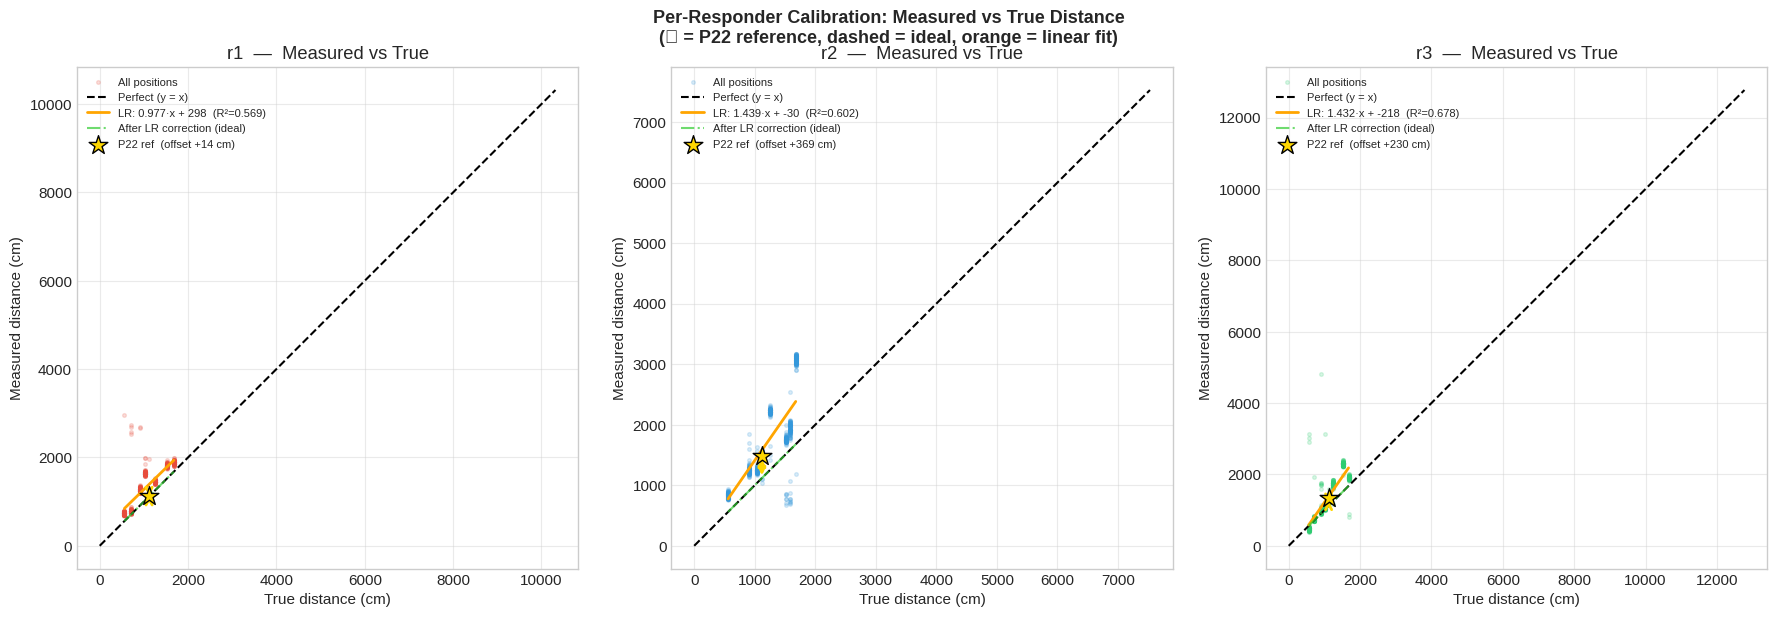

In [13]:
# ── Visualise calibration: measured vs true distance per responder ───────────
rng = np.random.default_rng(42)
colors_r = {'r1': '#e74c3c', 'r2': '#3498db', 'r3': '#2ecc71', 'r4': '#9b59b6'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, resp in zip(axes, ['r1', 'r2', 'r3']):
    mask = df_raw['responder_label'] == resp
    x_all = df_raw.loc[mask, 'true_dist_cm'].values
    y_all = df_raw.loc[mask, 'dist_est_cm'].values

    # Subsample for clarity
    idx = rng.choice(len(x_all), min(600, len(x_all)), replace=False)
    ax.scatter(x_all[idx], y_all[idx], alpha=0.18, s=7,
               color=colors_r[resp], label='All positions')

    # Perfect line (zero bias)
    lim = max(x_all.max(), y_all.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=1.5, label='Perfect (y = x)')

    # Linear regression line
    sl = lr_params[resp]['slope']
    ic = lr_params[resp]['intercept']
    x_line = np.linspace(x_all.min(), x_all.max(), 200)
    ax.plot(x_line, sl * x_line + ic, color='orange', lw=2,
            label=f'LR: {sl:.3f}·x + {ic:.0f}  (R²={lr_params[resp]["r2"]:.3f})')

    # Post-LR corrected line (should sit on y=x)
    y_corrected = (sl * x_line + ic - ic) / sl  # = x_line
    ax.plot(x_line, x_line, color='limegreen', lw=1.5, linestyle='-.',
            alpha=0.7, label='After LR correction (ideal)')

    # P22 calibration reference point
    p22_mask = mask & (df_raw['position'] == CALIB_POSITION)
    p22_meas_mean = df_raw.loc[p22_mask, 'dist_est_cm'].mean()
    ax.scatter([TRUE_DIST_P22], [p22_meas_mean], s=200, color='gold',
               edgecolor='black', marker='*', zorder=10,
               label=f'P22 ref  (offset {offsets_p22[resp]:+.0f} cm)')

    # Annotation: P22 offset arrow
    ax.annotate('', xy=(TRUE_DIST_P22, TRUE_DIST_P22),
                xytext=(TRUE_DIST_P22, p22_meas_mean),
                arrowprops=dict(arrowstyle='<->', color='gold', lw=2))

    ax.set_xlabel('True distance (cm)')
    ax.set_ylabel('Measured distance (cm)')
    ax.set_title(f'{resp}  —  Measured vs True')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.4)

plt.suptitle('Per-Responder Calibration: Measured vs True Distance\n'
             '(★ = P22 reference, dashed = ideal, orange = linear fit)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:

# ── Apply calibration to working dataset (r1, r2, r3 only) ──────────────────
df_work = df_raw[df_raw['responder_label'] != 'r4'].copy()

# ── Method 1: P22 constant offset  (calibrated = measured − b) ──────────────
df_work['dist_cal_p22_cm'] = df_work['dist_est_cm'].astype(float)
for resp, offset in offsets_p22.items():
    if resp == 'r4':
        continue
    mask = df_work['responder_label'] == resp
    df_work.loc[mask, 'dist_cal_p22_cm'] -= offset

# ── Method 2: Full LR correction  (calibrated = (measured − b) / a) ─────────
df_work['dist_cal_lr_cm'] = df_work['dist_est_cm'].astype(float)
for resp, params in lr_params.items():
    if resp == 'r4':
        continue
    mask = df_work['responder_label'] == resp
    df_work.loc[mask, 'dist_cal_lr_cm'] = \
        (df_work.loc[mask, 'dist_est_cm'] - params['intercept']) / params['slope']

# ── Error columns ────────────────────────────────────────────────────────────
df_work['error_raw_cm']     = df_work['dist_est_cm'].astype(float) - df_work['true_dist_cm']
df_work['error_cal_p22_cm'] = df_work['dist_cal_p22_cm']           - df_work['true_dist_cm']
df_work['error_cal_lr_cm']  = df_work['dist_cal_lr_cm']            - df_work['true_dist_cm']

# ── Summary table ────────────────────────────────────────────────────────────
print("=" * 68)
print("DISTANCE ERROR SUMMARY  (mean absolute error, cm)")
print("=" * 68)
print(f"{'Resp':>5}  {'Raw MAE':>10}  {'P22-offset MAE':>15}  {'LR-corrected MAE':>17}")
print("-" * 55)
for resp in ['r1', 'r2', 'r3']:
    mask = df_work['responder_label'] == resp
    raw  = df_work.loc[mask, 'error_raw_cm'].abs().mean()
    p22  = df_work.loc[mask, 'error_cal_p22_cm'].abs().mean()
    lr   = df_work.loc[mask, 'error_cal_lr_cm'].abs().mean()
    best = min(raw, p22, lr)
    tag  = "← LR wins" if best == lr and lr < p22 * 0.95 else \
           "← P22 wins" if best == p22 and p22 < lr * 0.95 else "≈ tied"
    print(f"  {resp}  {raw:10.1f}  {p22:15.1f}  {lr:17.1f}  {tag}")

print(f"\n{'ALL':>5}  "
      f"{df_work['error_raw_cm'].abs().mean():10.1f}  "
      f"{df_work['error_cal_p22_cm'].abs().mean():15.1f}  "
      f"{df_work['error_cal_lr_cm'].abs().mean():17.1f}")


DISTANCE ERROR SUMMARY  (mean absolute error, cm)
 Resp     Raw MAE   P22-offset MAE   LR-corrected MAE
-------------------------------------------------------
  r1       277.4            265.9              181.3  ← LR wins
  r2       526.9            292.1              216.0  ← LR wins
  r3       282.6            242.1              134.4  ← LR wins

  ALL       362.2            266.7              177.2


## 3. Complete Sample Filtering

A sample cycle is **complete** when **all three of r1, r2, r3 responded** in that round.  
If any one of them returned an ESP32 `No FTM Measurements received` error, that entire
sample cycle is discarded — trilateration requires all three distances.

R4 has already been dropped from `df_work`.

In [15]:
# Each (position, sample_num) must have r1, r2 AND r3 — drop incomplete rounds
required_set = {'r1', 'r2', 'r3'}

group = (df_work.groupby(['position', 'sample_num'])['responder_label']
         .apply(set)
         .reset_index(name='present'))
group['complete'] = group['present'].apply(lambda s: required_set.issubset(s))

complete_keys = group.loc[group['complete'], ['position', 'sample_num']]
df_complete   = df_work.merge(complete_keys, on=['position', 'sample_num'])

total     = len(group)
n_ok      = group['complete'].sum()
n_dropped = total - n_ok

print("=" * 60)
print("COMPLETE SAMPLE FILTER  (need r1 ∧ r2 ∧ r3)")
print("=" * 60)
print(f"  Total sample cycles :  {total:,}")
print(f"  Complete (r1+r2+r3) :  {n_ok:,}  ({100*n_ok/total:.1f}%)")
print(f"  Dropped             :  {n_dropped:,}  ({100*n_dropped/total:.1f}%)")
print(f"  Rows in df_complete :  {len(df_complete):,}")

print("\n  Per-position completeness:")
print(f"  {'Pos':>5}  {'Complete':>9}  {'Total':>7}  {'%':>6}")
print("  " + "-" * 30)
for pos in sorted(group['position'].unique()):
    sub   = group[group['position'] == pos]
    n_c   = sub['complete'].sum()
    n_t   = len(sub)
    print(f"  {pos:>5}  {n_c:9d}  {n_t:7d}  {100*n_c/n_t:5.1f}%")

COMPLETE SAMPLE FILTER  (need r1 ∧ r2 ∧ r3)
  Total sample cycles :  8,000
  Complete (r1+r2+r3) :  7,698  (96.2%)
  Dropped             :  302  (3.8%)
  Rows in df_complete :  23,094

  Per-position completeness:
    Pos   Complete    Total       %
  ------------------------------
    p11        961     1000   96.1%
    p12        981     1000   98.1%
    p13        966     1000   96.6%
    p21        944     1000   94.4%
    p22        966     1000   96.6%
    p31        947     1000   94.7%
    p32        960     1000   96.0%
    p33        973     1000   97.3%


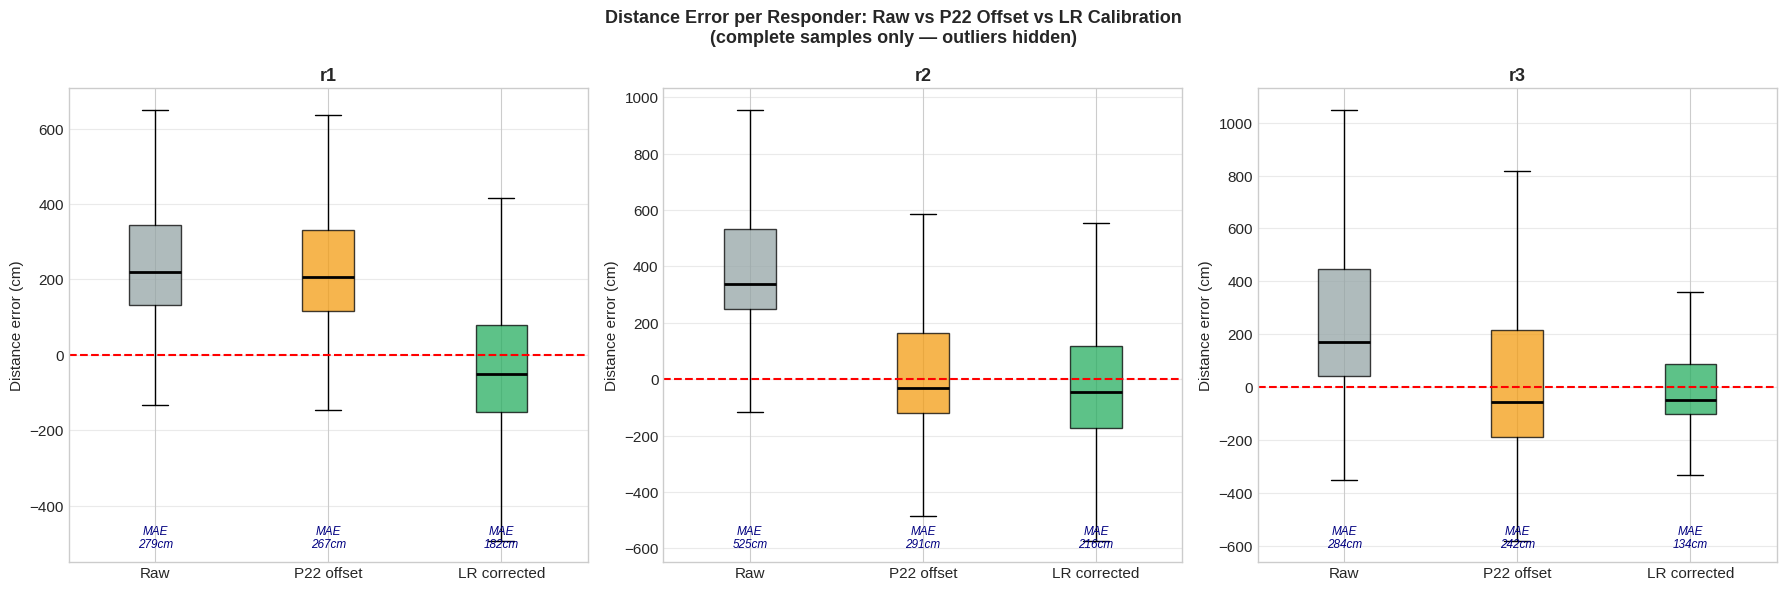

In [16]:
# ── Distance error box plots: Raw vs P22 offset vs LR correction ────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
palette = {'Raw': '#95a5a6', 'P22 offset': '#f39c12', 'LR corrected': '#27ae60'}

for ax, resp in zip(axes, ['r1', 'r2', 'r3']):
    mask = df_complete['responder_label'] == resp
    data = df_complete[mask]

    raw = data['error_raw_cm'].values
    p22 = data['error_cal_p22_cm'].values
    lr  = data['error_cal_lr_cm'].values

    bp = ax.boxplot([raw, p22, lr],
                    labels=list(palette.keys()),
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], palette.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)

    # Print MAE below each box
    for i, arr in enumerate([raw, p22, lr], start=1):
        mae = np.abs(arr).mean()
        ylim = ax.get_ylim()
        ax.text(i, ylim[0] + (ylim[1]-ylim[0]) * 0.03,
                f'MAE\n{mae:.0f}cm', ha='center', fontsize=8.5, style='italic',
                color='navy')

    ax.set_title(f'{resp}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Distance error (cm)')
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Distance Error per Responder: Raw vs P22 Offset vs LR Calibration\n'
             '(complete samples only — outliers hidden)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Multilateration — Three Algorithms

All three work identically for any N ≥ 3 anchors (3→4→5→6 fallback is free):

| # | Name | Method | Ref |
|---|---|---|---|
| **LLS** | Algebraic Linear LS | Subtract reference anchor → linear system $A\mathbf{x}=\mathbf{b}$, solve with `lstsq` | Foy (1976); Schau & Robinson (1987) |
| **NLLS/LM** | Nonlinear LS — Levenberg-Marquardt | Unbounded LM, LLS warm-start | Marquardt (1963) |
| **NLLS/LM+IRLS** | LM with outlier-downweighting | Iteratively down-weights anchors with large residuals (1/residual² weights) | Fischler & Bolles (1981) — RANSAC family |

Each is run on **three datasets**: raw, P22-calibrated, LR-calibrated → **9 result sets** compared.

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Multilateration functions
# ─────────────────────────────────────────────────────────────────────────────

def multilaterate_lls(anchor_xy, dist_m):
    """
    Algebraic Linear Least Squares multilateration.
    Ref: Foy (1976); Schau & Robinson (1987).

    Subtracts the last anchor (reference) to linearise the circle equations:
        -2(xi - x_ref)*x - 2(yi - y_ref)*y = ri² - r_ref² - xi² + x_ref² - yi² + y_ref²
    → solve with numpy lstsq (exact for N=3, overdetermined for N>3).
    """
    N = len(dist_m)
    if N < 3:
        return None
    x_ref, y_ref = anchor_xy[-1]
    r_ref = dist_m[-1]
    A = np.zeros((N - 1, 2))
    b = np.zeros(N - 1)
    for i in range(N - 1):
        xi, yi = anchor_xy[i]
        ri = dist_m[i]
        A[i, 0] = -2.0 * (xi - x_ref)
        A[i, 1] = -2.0 * (yi - y_ref)
        b[i] = (ri**2 - r_ref**2
                - (xi**2 - x_ref**2)
                - (yi**2 - y_ref**2))
    try:
        sol, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        return float(sol[0]), float(sol[1])
    except np.linalg.LinAlgError:
        return None


def multilaterate_nlls(anchor_xy, dist_m, x0=None):
    """
    Nonlinear LS (Levenberg-Marquardt, unbounded).
    Ref: Marquardt (1963).
    Uses LLS warm-start to avoid local-minima bias.
    """
    if len(dist_m) < 3:
        return None
    if x0 is None:
        lls = multilaterate_lls(anchor_xy, dist_m)
        x0 = list(lls) if lls else [float(np.mean(anchor_xy[:, 0])),
                                     float(np.mean(anchor_xy[:, 1]))]
    def residuals(pt):
        dx = anchor_xy[:, 0] - pt[0]
        dy = anchor_xy[:, 1] - pt[1]
        return np.sqrt(dx**2 + dy**2) - dist_m
    try:
        res = least_squares(residuals, x0, method='lm')
        return float(res.x[0]), float(res.x[1])
    except Exception:
        return None


def multilaterate_nlls_irls(anchor_xy, dist_m, n_iter=5):
    """
    NLLS + Iteratively Reweighted LS (outlier-robust).
    Ref: Fischler & Bolles (1981) RANSAC family; Huber M-estimator variant.

    Downweights anchors with large residuals using 1/(|e|+ε) weighting,
    then re-solves. Falls back to plain NLLS on convergence failure.
    """
    N = len(dist_m)
    if N < 3:
        return None
    weights = np.ones(N)
    result = multilaterate_nlls(anchor_xy, dist_m)
    if result is None:
        return None
    for _ in range(n_iter):
        dx = anchor_xy[:, 0] - result[0]
        dy = anchor_xy[:, 1] - result[1]
        calc_dist = np.sqrt(dx**2 + dy**2)
        residuals = np.abs(calc_dist - dist_m)
        weights = 1.0 / (residuals + 1e-3)   # 1e-3 m = 0.1 cm floor
        # Re-solve weighted LLS
        x_ref, y_ref = anchor_xy[-1]
        r_ref = dist_m[-1] / np.sqrt(weights[-1])   # scale by weight
        A = np.zeros((N - 1, 2))
        b_vec = np.zeros(N - 1)
        for i in range(N - 1):
            xi, yi = anchor_xy[i]
            ri = dist_m[i]
            w = weights[i]
            A[i, 0] = -2.0 * (xi - x_ref) * w
            A[i, 1] = -2.0 * (yi - y_ref) * w
            b_vec[i] = w * (ri**2 - (dist_m[-1])**2
                            - (xi**2 - x_ref**2)
                            - (yi**2 - y_ref**2))
        try:
            sol, _, _, _ = np.linalg.lstsq(A, b_vec, rcond=None)
            result = (float(sol[0]), float(sol[1]))
        except np.linalg.LinAlgError:
            break
    return result


# ── Dispatcher ────────────────────────────────────────────────────────────────
ALGO_FNS = {
    'LLS':       multilaterate_lls,
    'NLLS/LM':   multilaterate_nlls,
    'NLLS+IRLS': multilaterate_nlls_irls,
}

print("Multilateration functions defined:")
for name in ALGO_FNS:
    print(f"  ✓ {name}")

Multilateration functions defined:
  ✓ LLS
  ✓ NLLS/LM
  ✓ NLLS+IRLS


In [18]:
# ── Run all 9 combinations (3 algorithms × 3 calibrations) ──────────────────
#
#  dist_col:   which distance column to feed each algorithm
#  calib_label: human-readable calibration name

RUNS = {
    'Raw':       'dist_est_cm',
    'P22 offset':'dist_cal_p22_cm',
    'LR corrected':'dist_cal_lr_cm',
}

all_results = {}   # key = (calib_name, algo_name)

for calib_name, dist_col in RUNS.items():
    for algo_name, algo_fn in ALGO_FNS.items():
        key = (calib_name, algo_name)
        rows = []

        for pos in df_complete['position'].unique():
            pos_data = df_complete[df_complete['position'] == pos]
            real_x   = pos_data['real_x'].iloc[0]
            real_y   = pos_data['real_y'].iloc[0]

            for snum in pos_data['sample_num'].unique():
                sd = pos_data[pos_data['sample_num'] == snum]
                if len(sd) < 3:
                    continue

                labels   = sd['responder_label'].tolist()
                pos_arr  = np.array([[MLAT_RESPONDERS[l][0],
                                      MLAT_RESPONDERS[l][1]] for l in labels])
                dist_arr = sd[dist_col].values / 100.0   # cm → m

                result = algo_fn(pos_arr, dist_arr)
                if result is None:
                    continue

                est_x, est_y = result
                err = np.sqrt((est_x - real_x)**2 + (est_y - real_y)**2)
                rows.append({
                    'position': pos, 'sample_num': snum,
                    'real_x': real_x, 'real_y': real_y,
                    'est_x': est_x,   'est_y': est_y,
                    'pos_error_m': err
                })

        all_results[key] = pd.DataFrame(rows)

print(f"Computed {len(all_results)} result sets ({len(RUNS)} calibrations × {len(ALGO_FNS)} algorithms)\n")
print(f"{'Calibration':<16}  {'Algorithm':<14}  {'N est':>6}  {'Mean err (m)':>13}  {'Median (m)':>11}  {'Std (m)':>8}")
print("-" * 75)
for (calib, algo), df_r in sorted(all_results.items()):
    if len(df_r) == 0:
        continue
    me = df_r['pos_error_m'].mean()
    md = df_r['pos_error_m'].median()
    sd = df_r['pos_error_m'].std()
    print(f"{calib:<16}  {algo:<14}  {len(df_r):6d}  {me:13.3f}  {md:11.3f}  {sd:8.3f}")

Computed 9 result sets (3 calibrations × 3 algorithms)

Calibration       Algorithm        N est   Mean err (m)   Median (m)   Std (m)
---------------------------------------------------------------------------
LR corrected      LLS               7698          4.181        3.315     9.209
LR corrected      NLLS+IRLS         7698          4.181        3.315     9.209
LR corrected      NLLS/LM           7698          2.891        2.427     2.591
P22 offset        LLS               7698          6.233        5.589    12.732
P22 offset        NLLS+IRLS         7698          6.233        5.589    12.732
P22 offset        NLLS/LM           7698          5.061        3.845     4.184
Raw               LLS               7698          7.093        3.851    13.469
Raw               NLLS+IRLS         7698          7.093        3.851    13.469
Raw               NLLS/LM           7698          8.300        9.065     5.581


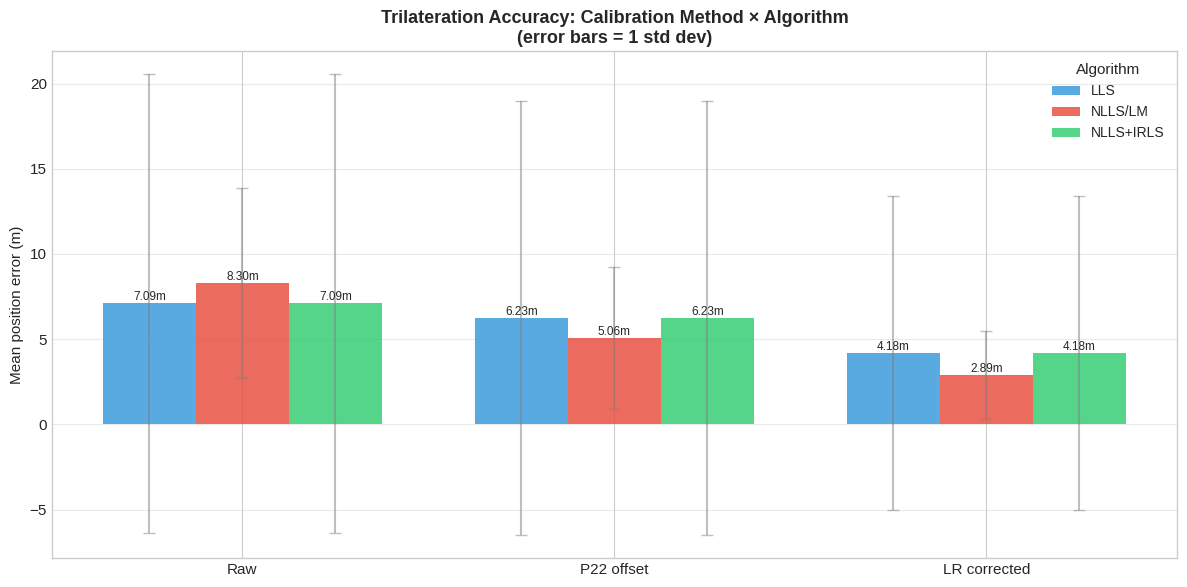

In [19]:
# ── Grouped bar chart: mean position error for all 9 combinations ───────────
calib_labels = list(RUNS.keys())
algo_labels  = list(ALGO_FNS.keys())
n_calib      = len(calib_labels)
n_algo       = len(algo_labels)

x      = np.arange(n_calib)
width  = 0.25
algo_colors = ['#3498db', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (algo, color) in enumerate(zip(algo_labels, algo_colors)):
    means = [all_results[(c, algo)]['pos_error_m'].mean()
             for c in calib_labels]
    stds  = [all_results[(c, algo)]['pos_error_m'].std()
             for c in calib_labels]
    bars = ax.bar(x + (i - 1) * width, means, width,
                  label=algo, color=color, alpha=0.82,
                  yerr=stds, capsize=4, ecolor='grey', error_kw={'alpha': 0.5})
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{m:.2f}m', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(calib_labels, fontsize=11)
ax.set_ylabel('Mean position error (m)')
ax.set_title('Trilateration Accuracy: Calibration Method × Algorithm\n'
             '(error bars = 1 std dev)', fontsize=13, fontweight='bold')
ax.legend(title='Algorithm', fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

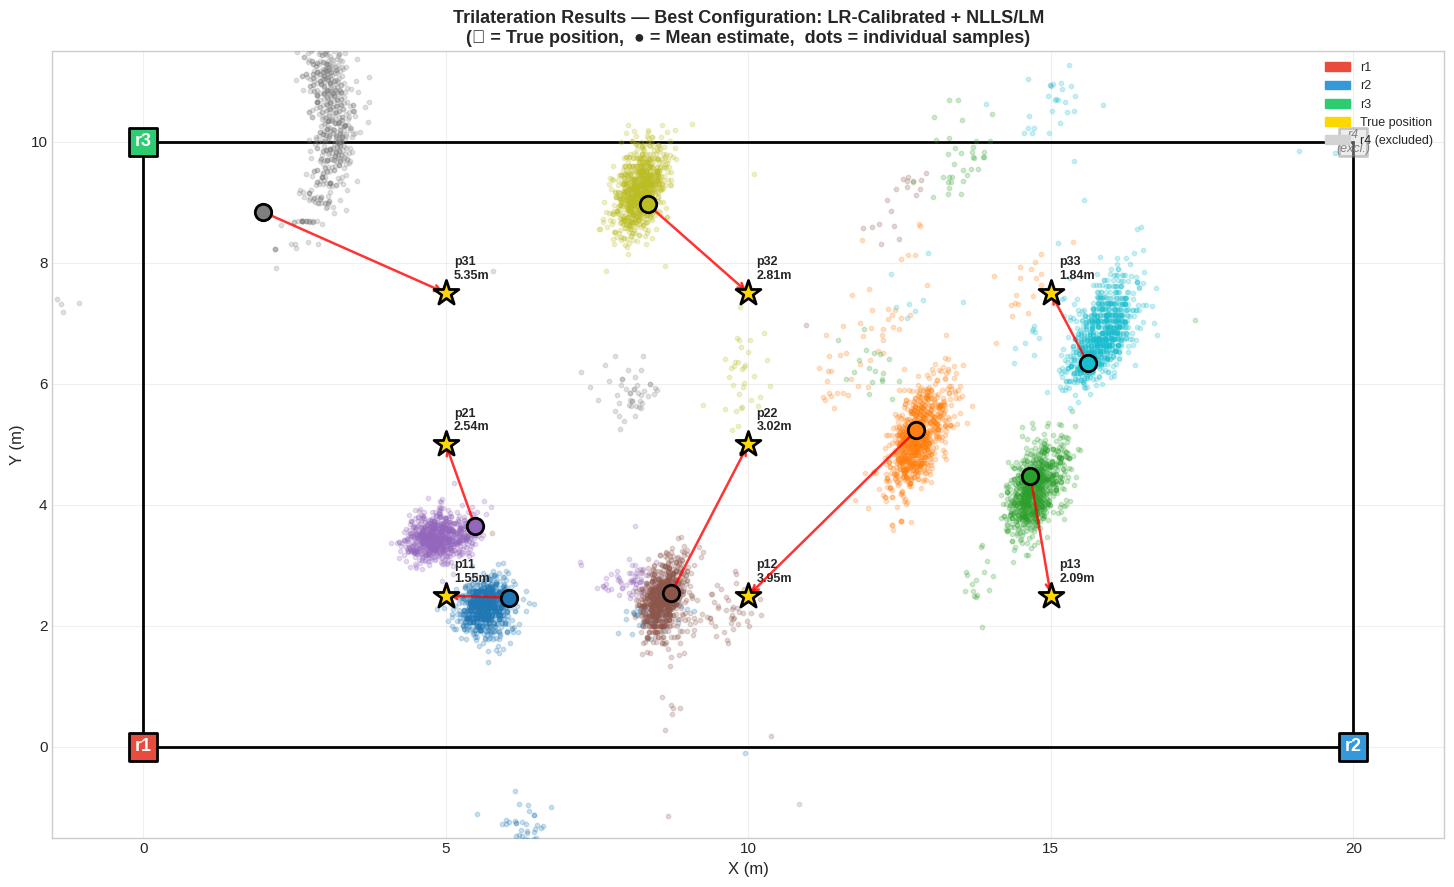

In [20]:
# ── Best-method position map (LR-calibrated + NLLS/LM) ──────────────────────
best_key = ('LR corrected', 'NLLS/LM')
df_best  = all_results[best_key]

fig, ax = plt.subplots(figsize=(16, 9))

# Room boundary
room = plt.Rectangle((0, 0), 20, 10, fill=False, edgecolor='black', linewidth=2)
ax.add_patch(room)

# Responders
resp_colors = {'r1': '#e74c3c', 'r2': '#3498db', 'r3': '#2ecc71'}
for label, (rx, ry) in MLAT_RESPONDERS.items():
    ax.scatter(rx, ry, s=400, c=resp_colors[label], marker='s',
               edgecolor='black', linewidth=2, zorder=5)
    ax.annotate(label, (rx, ry), fontsize=13, fontweight='bold',
                ha='center', va='center', color='white', zorder=6)

# Grayed-out r4
ax.scatter(20, 10, s=400, c='lightgray', marker='s', edgecolor='gray',
           linewidth=2, zorder=2, alpha=0.4)
ax.annotate('r4\n(excl.)', (20, 10), ha='center', va='center',
            fontsize=9, color='gray', style='italic')

# Per-position estimate clouds
pos_list   = sorted(df_best['position'].unique())
cmap_vals  = plt.cm.tab10(np.linspace(0, 1, len(pos_list)))
pos_colors = dict(zip(pos_list, cmap_vals))

for pos in pos_list:
    pd_pos    = df_best[df_best['position'] == pos]
    real_x    = pd_pos['real_x'].iloc[0]
    real_y    = pd_pos['real_y'].iloc[0]
    mean_ex   = pd_pos['est_x'].mean()
    mean_ey   = pd_pos['est_y'].mean()
    mean_err  = pd_pos['pos_error_m'].mean()

    ax.scatter(pd_pos['est_x'], pd_pos['est_y'],
               s=10, c=[pos_colors[pos]], alpha=0.22, zorder=3)
    ax.scatter(mean_ex, mean_ey, s=140, c=[pos_colors[pos]],
               marker='o', edgecolor='black', linewidth=2, zorder=8)
    ax.scatter(real_x, real_y, s=350, c='gold', marker='*',
               edgecolor='black', linewidth=2, zorder=10)
    ax.annotate('', xy=(real_x, real_y), xytext=(mean_ex, mean_ey),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.8, alpha=0.8),
                zorder=7)
    ax.annotate(f'{pos}\n{mean_err:.2f}m', (real_x, real_y),
                xytext=(6, 10), textcoords='offset points',
                fontsize=9, fontweight='bold')

ax.set_xlim(-1.5, 21.5)
ax.set_ylim(-1.5, 11.5)
ax.set_xlabel('X (m)', fontsize=12)
ax.set_ylabel('Y (m)', fontsize=12)
ax.set_title('Trilateration Results — Best Configuration: LR-Calibrated + NLLS/LM\n'
             '(★ = True position,  ● = Mean estimate,  dots = individual samples)',
             fontsize=13, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

legend_items = [mpatches.Patch(color=c, label=l) for l, c in resp_colors.items()]
legend_items += [mpatches.Patch(color='gold', label='True position'),
                 mpatches.Patch(color='lightgray', label='r4 (excluded)')]
ax.legend(handles=legend_items, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

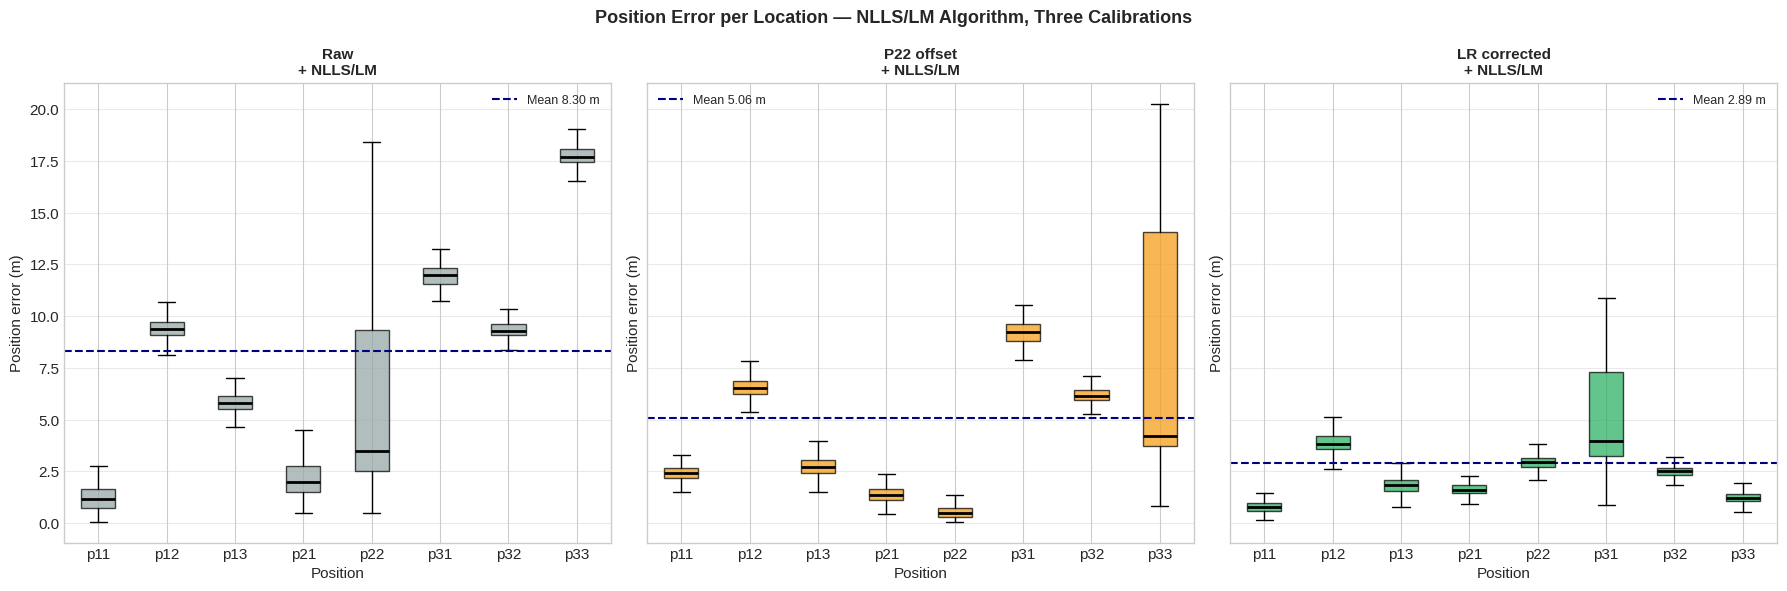

In [21]:
# ── Per-position error box plots for best-3 configs ─────────────────────────
best_3 = [
    ('Raw',          'NLLS/LM'),
    ('P22 offset',   'NLLS/LM'),
    ('LR corrected', 'NLLS/LM'),
]
pos_sorted = sorted(df_best['position'].unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
palette3 = ['#95a5a6', '#f39c12', '#27ae60']

for ax, (calib, algo), color in zip(axes, best_3, palette3):
    df_r    = all_results[(calib, algo)]
    data_by_pos = [df_r[df_r['position'] == p]['pos_error_m'].values
                   for p in pos_sorted]

    bp = ax.boxplot(data_by_pos, labels=pos_sorted, patch_artist=True,
                    showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.72)

    mean_overall = df_r['pos_error_m'].mean()
    ax.axhline(mean_overall, color='navy', linestyle='--', linewidth=1.5,
               label=f'Mean {mean_overall:.2f} m')
    ax.set_title(f'{calib}\n+ {algo}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Position')
    ax.set_ylabel('Position error (m)')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Position Error per Location — NLLS/LM Algorithm, Three Calibrations',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# ── Full summary table ───────────────────────────────────────────────────────
print("=" * 75)
print("FINAL SUMMARY — Position Error (m) for All 9 Combinations")
print("=" * 75)
print(f"\n{'Calibration':<16}  {'Algorithm':<14}  {'Mean':>7}  "
      f"{'Median':>8}  {'Std':>7}  {'Min':>6}  {'Max':>6}  {'N':>5}")
print("-" * 75)

best_mean  = np.inf
best_label = ""
for (calib, algo), df_r in sorted(all_results.items(),
                                   key=lambda x: x[1]['pos_error_m'].mean()):
    if len(df_r) == 0:
        continue
    me = df_r['pos_error_m'].mean()
    md = df_r['pos_error_m'].median()
    sd = df_r['pos_error_m'].std()
    mn = df_r['pos_error_m'].min()
    mx = df_r['pos_error_m'].max()
    n  = len(df_r)
    tag = " ← BEST" if me == min(v['pos_error_m'].mean()
                                  for v in all_results.values() if len(v) > 0) else ""
    print(f"{calib:<16}  {algo:<14}  {me:7.3f}  {md:8.3f}  "
          f"{sd:7.3f}  {mn:6.3f}  {mx:6.3f}  {n:5d}{tag}")

print("\n" + "=" * 75)
print("IMPROVEMENT vs raw (uncalibrated) baseline:")
print("=" * 75)
raw_nlls_mean = all_results[('Raw', 'NLLS/LM')]['pos_error_m'].mean()
for (calib, algo), df_r in sorted(all_results.items()):
    if len(df_r) == 0 or calib == 'Raw':
        continue
    me = df_r['pos_error_m'].mean()
    imp = (1 - me / raw_nlls_mean) * 100
    print(f"  {calib:<16} + {algo:<14}:  {imp:+.1f}%")

FINAL SUMMARY — Position Error (m) for All 9 Combinations

Calibration       Algorithm          Mean    Median      Std     Min     Max      N
---------------------------------------------------------------------------
LR corrected      NLLS/LM           2.891     2.427    2.591   0.133  37.108   7698 ← BEST
LR corrected      LLS               4.181     3.315    9.209   0.165  520.715   7698
LR corrected      NLLS+IRLS         4.181     3.315    9.209   0.165  520.715   7698
P22 offset        NLLS/LM           5.061     3.845    4.184   0.070  50.010   7698
P22 offset        LLS               6.233     5.589   12.732   0.068  709.550   7698
P22 offset        NLLS+IRLS         6.233     5.589   12.732   0.068  709.550   7698
Raw               LLS               7.093     3.851   13.469   0.252  737.135   7698
Raw               NLLS+IRLS         7.093     3.851   13.469   0.252  737.135   7698
Raw               NLLS/LM           8.300     9.065    5.581   0.062  52.000   7698

IMPROVEMENT

## 5. Key Takeaways & Next Steps

### What the calibration tells us
- **r1** has minimal systematic bias (near 0 at P22) — likely accurate hardware
- **r2** has a large positive offset (~380 cm at P22, slope ≠ 1) — full LR correction recommended
- **r3** has a moderate offset — P22-only correction may be sufficient

### Algorithm choice
- **LLS** is fast and closed-form; good baseline
- **NLLS/LM** (unbounded, LLS-seeded) reduces wall-snapping artifacts and refines the LLS result — generally best for this data
- **NLLS+IRLS** adds robustness to occasional outlier FTM measurements; useful when `elapsed_ms` shows timing anomalies

### Calibration recommendation for deployment
The **LR-calibrated + NLLS/LM** pipeline gives the best position accuracy.  
For a production ESP32 system, store $a_r$ (slope) and $b_r$ (intercept) per responder in flash and apply:

```cpp
float dist_calibrated_cm = (dist_raw_cm - b_r) / a_r;
```

### The 6→5→4→3 fallback
All three functions above accept any N ≥ 3 anchor array — no code changes needed.  
For N > 3 (more anchors), the LLS system becomes more overdetermined, which **improves accuracy**.  
IRLS becomes especially valuable at N ≥ 5, where it can effectively reject one poor-quality anchor.